In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO, SLA, DOT
from functions import Functions
from OceanDataStore import OceanDataCatalog


pfns = PlottingFns()
fns = Functions()


In [4]:
import gsw
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import xesmf as xe
import glob

fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'
fname_sose = '../data/SOSE/adelie3d/Jenny_AdelieSlices'
fname_snow = '../data/SOSE/Jenny_AdelieSlices_SIhsnow'

In [5]:
extent = [138, 150,-68,-64]


In [6]:
#get sose
sose=xr.open_mfdataset(glob.glob(fname_sose + '/*.nc'))

In [7]:
sosesnow = xr.open_mfdataset(glob.glob(fname_snow + '/*.nc'))

In [10]:
sose['SIhsnow'] = sosesnow.SIhsnow

In [12]:
# load SLA
sla = SLA(deg=0.25).da
dot = DOT(ver='egm').ds.dot

In [13]:

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

# CROP SLA
sla = fns.crop_to_extent(sla,extent)
dot = fns.crop_to_extent(dot,extent)

# convert to m
sla = sla / 100
dot = dot / 100

# define time bounds covering both datasets
t1 = sose.time[0]
t2 = sla.time[-1]

# take new anomaly
sla = sla - sla.sel(time=slice(t1,t2)).mean('time')
dot = dot - dot.sel(time=slice(t1,t2)).mean('time')

In [14]:
# sose ssh
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (sose.SIheff * rho_ice) + (sose.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
etan = (sose.ETAN + sload)

# compute SOSE ssh anomaly wrt to same mean as SLA
etan = etan - etan.sel(time=slice(t1,t2)).mean('time')
etan = etan.resample({'time':'MS'}).mean()

etan.load()

sose_ssh = etan.copy()

In [15]:
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))
glorys = fns.crop_to_extent(glorys,extent)
glorys_ssh = glorys.zos
# make monthly
glorys_ssh = glorys_ssh.resample({'time':'MS'}).mean()
# relative anomaly wrt common time period
glorys_ssh = glorys_ssh - glorys_ssh.sel(time=slice(t1,t2)).mean('time')

/tmp/ipykernel_3155181/1652886785.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))


In [16]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',variable_names=['zos'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to time
nemo_ssh = nemo.zos.where(mask,drop=True)
# make monthly
nemo_ssh = nemo_ssh.resample({'time_counter':'MS'}).mean()
# relative anomaly wrt common time period
nemo_ssh = nemo_ssh - nemo_ssh.sel(time_counter=slice(t1,t2)).mean('time_counter')


  2026-05-21T07:12:48.874509Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: HTTP read timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: HttpTimeoutError { kind: "HTTP read", duration: 1s }, connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [17]:
# rename
nemo_ssh = nemo_ssh.rename({'time_counter':'time'})

In [18]:
nemo_ssh.load()

<xarray.DataArray 'zos' (time: 594, y: 177, x: 190)> Size: 80MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.00566387, -0.00683796, -0.00794578, ...,  0.08746421,
          0.08688831,  0.08499944],
        [ 0.00173187,  0.00105   ,  0.0003581 , ...,  0.08787727,
          0.08744371,  0.08567798],
        [ 0.00783134,  0.00723219,  0.00656044, ...,  0.08751774,
          0.08729327,  0.08574092]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [-0.08571947, -0.08584893, -0.08555448, ..., -0.01195002,
         -0.00558293,  0.00047028],
        [-0.08348644, -0.08360183, -0.08333457, ..., -0.01021588,
         -0.0039835 ,  0.0019834 ],
        [-0.08259559, -0.08262515, -0.08225644, ..., -0.00758648,
         -0.00171876,  0.00392568]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.08379221, -0.07315421, -0.06392074, ...,  0.00565779,
          0.00535607,  0.00625122],
        [-0.07647479, -0.06739151, -0.05950797, ...,  0.00895739,
          0.0086894 ,  0.00952673],
        [-0.06815624, -0.06071293, -0.05427325, ...,  0.01238096,
          0.01219976,  0.01299989]]], shape=(594, 177, 190), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-06-01
  * y        (y) int64 1kB 883 884 885 886 887 888 ... 1055 1056 1057 1058 1059
  * x        (x) int64 2kB 770 771 772 773 774 775 ... 954 955 956 957 958 959
    nav_lat  (y, x) float64 269kB -68.95 -68.95 -68.95 ... -63.04 -63.04 -63.04
    nav_lon  (y, x) float64 269kB 137.2 137.2 137.3 137.4 ... 152.8 152.8 152.9
Attributes:
    standard_name:       sea_surface_height_above_geoid
    long_name:           Sea Surface Height Above Geoid
    units:               m
    online_operation:    average
    interval_operation:  450 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 450 s)

In [22]:
#averageacross whole area
#sose_mean = etan.mean(['XC','YC'])
nemo_mean = nemo_ssh.mean(['x','y'])
sla_mean = sla.mean(['latitude','longitude'])
dot_mean = dot.mean(['latitude','longitude'])
glorys_mean = glorys_ssh.mean(['latitude','longitude'])
sose_mean = sose_ssh.mean(['XC','YC'])


In [23]:
# assign colours for easy plotting
colors = {'GLORYS':'lightseagreen',
          'NEMO':'palevioletred',
          'SOSE':'orange',
          'SLA':'cornflowerblue',
          'DOT':'mediumpurple'}



Text(0, 0.5, 'sla (cm)')

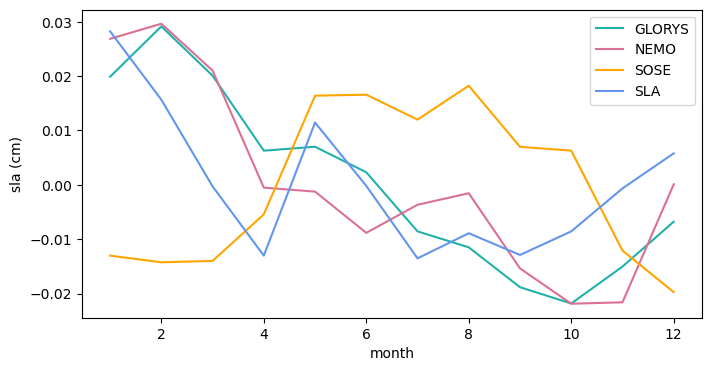

In [24]:
# compare climatologies
fig,ax = plt.subplots(figsize=(8,4))

for c, da in zip(colors.keys(),[glorys_mean,nemo_mean,sla_mean,dot_mean]):
    clim=da.sel(time=slice(t1,t2)).groupby('time.month').mean()
    ax.plot(clim.month,clim,label=c,c=colors[c])


ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')


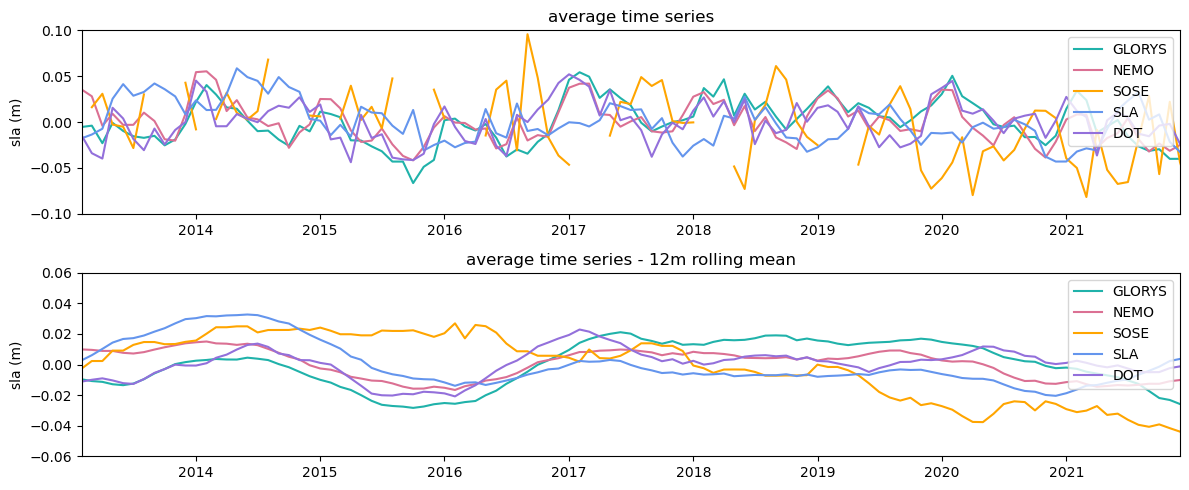

In [26]:
# compare time series
fig,axs = plt.subplots(2,1,figsize=(12,5))

for c, da in zip(colors.keys(),[glorys_mean,nemo_mean,sose_mean,sla_mean,dot_mean]):
    axs[0].plot(da.time,da,label=c,c=colors[c])
    axs[1].plot(da.time,da.rolling({'time':12},center=True,min_periods=6).mean(),c=colors[c],label=c)


ax=axs[0]
ax.set_title('average time series')
ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])
ax.set_ylim([-0.1,0.1])

ax=axs[1]
ax.set_title('average time series - 12m rolling mean')
ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])
ax.set_ylim([-0.06,0.06])



plt.tight_layout()

In [149]:
pgn_tsose=pgn.sel(time=slice(t0,t2))

[None, None, None, None]

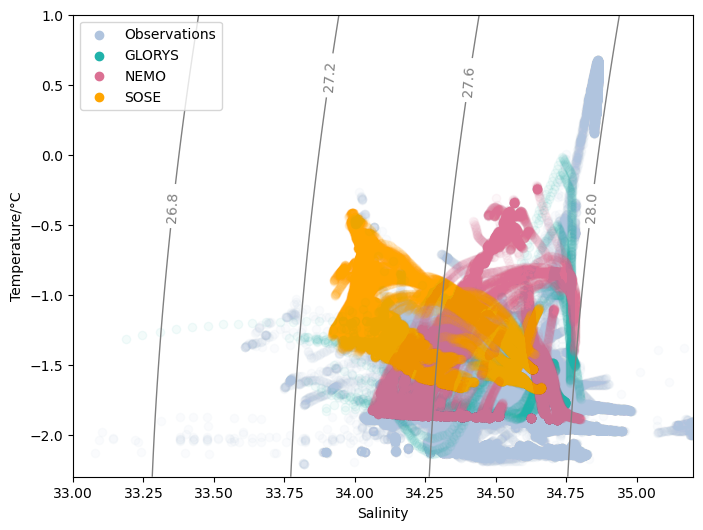

In [150]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
alpha=0.05
ims = []

for src in pgn.source.data:
    pgns = pgn_tsose.sel(source=src)
    ims.append(ax.scatter(pgns.asal,pgns.ctemp,alpha=alpha,c=pgns.colors.item(),label=src))


tlim=[-2.3,1]
slim=[33,35.2]
temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)
ax.set_ylabel('Temperature/°C')
ax.set_xlabel('Salinity')

[im.set_alpha(1) for im in ims]
ax.legend()
[im.set_alpha(alpha) for im in ims]

In [151]:
pgn_600=pgn_tsose.sel(pres=slice(0,600))

In [152]:
def get_depthclass(z):
    if z < 100:
        return '0-100dbar'
    elif z < 300:
        return '100-300dbar'
    elif z < 600:
        return '300-600dbar'

pgn_600['depthclass'] = xr.DataArray([get_depthclass(z) for z in pgn_600.pres.data],coords={'pres':pgn_600.pres})

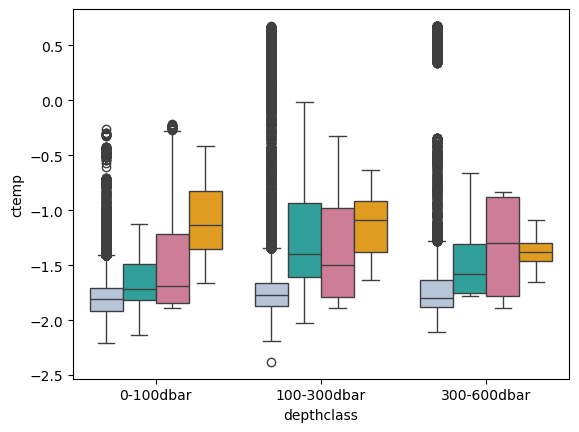

In [153]:
pgn_df = pgn_600.to_dataframe().reset_index().dropna()
sns.boxplot(data=pgn_df, x="depthclass", y="ctemp", hue="source", palette=pgn_600.colors.data)
plt.legend([],[], frameon=False)


In [25]:
pgn['year']=pgn.time.dt.year
pgn['month']=pgn.time.dt.year

pgn_dfy=pgn.resample({'time':'YS'}).mean().to_dataframe().reset_index().dropna()

In [26]:
pgn_dfy

,source,pres,time,asal,ctemp,colors,depthclass,year,month
37,Observations,4,2008-01-01,33.569366,-0.954124,lightsteelblue,0-100dbar,2008.0,2008.0
39,Observations,4,2010-01-01,34.233818,-1.456096,lightsteelblue,0-100dbar,2010.0,2010.0
43,Observations,4,2014-01-01,34.663273,-1.790467,lightsteelblue,0-100dbar,2014.0,2014.0
44,Observations,4,2015-01-01,34.596455,-1.689573,lightsteelblue,0-100dbar,2015.0,2015.0
46,Observations,4,2017-01-01,34.423882,-1.838643,lightsteelblue,0-100dbar,2017.0,2017.0
...,...,...,...,...,...,...,...,...,...
16219,NEMO,598,2008-01-01,17.356516,-0.741596,palevioletred,300-600dbar,2008.0,2008.0
16220,NEMO,598,2009-01-01,34.743046,-1.299004,palevioletred,300-600dbar,2009.0,2009.0
16222,NEMO,598,2011-01-01,34.645855,-1.671727,palevioletred,300-600dbar,2011.0,2011.0
16228,NEMO,598,2017-01-01,34.715115,-1.797238,palevioletred,300-600dbar,2017.0,2017.0


<Axes: xlabel='time', ylabel='ctemp'>

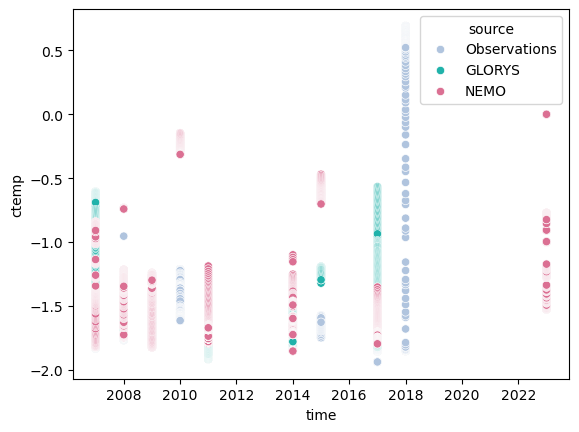

In [27]:
sns.scatterplot(data=pgn_dfy,x='time',y='ctemp',hue='source',palette=colors)#,errorbar=None)#("pi",95))

In [ ]:
seasons = fns.season_split(pgn.sel(pres=slice(100,300)).mean('pres'))
colors = plt.cm.summer(np.linspace(0, 1, 4))


In [36]:
data

<xarray.DataArray 'ctemp' (source: 3, year: 11)> Size: 132B
array([[-1.8581681, -1.7408427, -1.6753887,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan],
       [       nan,        nan, -1.655511 ,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan],
       [-1.8745599, -1.8821613, -1.6710415,        nan,        nan,
               nan,        nan,        nan,        nan, -1.8852196,
               nan]], dtype=float32)
Coordinates:
  * source   (source) <U12 144B 'Observations' 'GLORYS' 'NEMO'
  * year     (year) int64 88B 2007 2008 2009 2010 2011 ... 2017 2018 2023 2024
Attributes:
    long_name:      Conservative Temperature
    standard_name:  CTEMP
    units:          degrees_Celcius

In [40]:
en4 = xr.open_dataset('EN4')

FileNotFoundError: No such file: 'EN4'

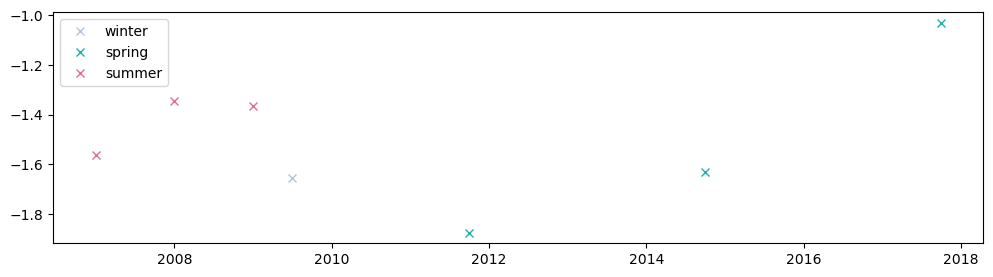

In [39]:
fig,ax= plt.subplots(figsize=(12,3))
offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
for c,s in zip(colors,seasons):
    data = seasons[s].sel(source='GLORYS').ctemp.groupby('time.year').mean()
    ax.plot(data.year+offset[s],data,marker='x',label=s,linestyle='None',c=c)
ax.legend()